In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/byuidatascience/data4python4ds/master/data-raw/flights/flights.csv"
flights = pd.read_csv(url)



In [2]:
# In the month of June, was there a difference in the average departure delay of flights between LaGuardia and John F. Kennedy airports? Let's calculate it.

flights_jfk_lga = flights[(flights['origin'] == 'JFK') | (flights['origin'] == 'LGA')]
# restrict the month to June
flights_jfk_lga = flights_jfk_lga[flights_jfk_lga['month'] == 6]

# Calculate the average departure delay (dep_delay) from each origin
avg_dep_delay = flights_jfk_lga.groupby('origin')['dep_delay'].mean()
delay_diff = avg_dep_delay['JFK'] - avg_dep_delay['LGA']

print("The difference in average departure delay between JFK and LGA is: ", round(delay_diff,ndigits = 3), "minutes")

The difference in average departure delay between JFK and LGA is:  1.203 minutes


In [3]:
# There is a difference- but is this a significant difference? Let's conduct a hypothesis test. First, let's get clear on what our null and alternative hypotheses are.

# : There is no difference in the average departure delays of flights from LGA and JFK airports.
# : There is a difference in the average departure delays of flights from LGA and JFK airports.


# Step 1. Define the shuffling procedure.

# Let's write a function that shuffles the 'origin' column of the flights dataset and then calculates the difference in the average departure delays of the two groups.

def shuffle(df):
    # shuffle the 'origin' column
    df.loc[:,'origin'] = np.random.permutation(df['origin'])
    #df['origin'] = np.random.permutation(df['origin'])
    # calculate the average departure delay from each origin
    avg_dep_delay = df.groupby('origin')['dep_delay'].mean()
    # calculate the difference in average departure delay between JFK and LGA
    delay_diff = avg_dep_delay['JFK'] - avg_dep_delay['LGA']
    return delay_diff


# And let's bring back our helper function from the videos for running many simulations of the shuffling procedure. 

def simulate_sampling_distribution(
    underlying_distribution_simulator, sample_statistic, n_simulations=1000, sample_size=100
):
    samples = [underlying_distribution_simulator(sample_size) for _ in range(n_simulations)]
    return pd.DataFrame(
        {
            "statistic": [sample_statistic(sample) for sample in samples],
        }
    )

<Axes: xlabel='statistic', ylabel='Count'>

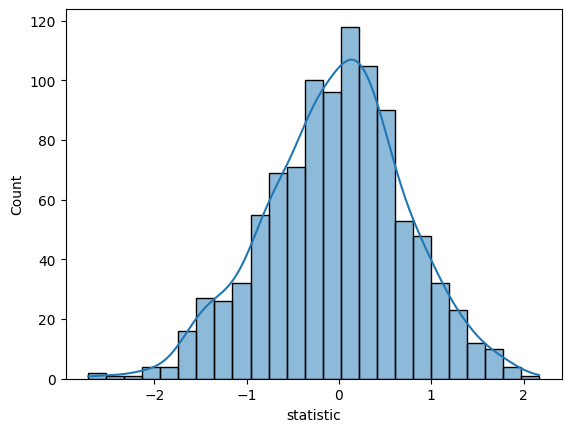

In [4]:
# Step 2. Simulate the sampling distribution¶

# Let's run 1000 simulations and plot the sampling distribution of the difference in average delays.

sample_means = simulate_sampling_distribution(
    lambda n: shuffle(flights_jfk_lga),
    lambda x: x.mean(),
    n_simulations=1000,
    sample_size=len(flights_jfk_lga),
)

# plot a histogram of sample means in seaborn
sns.histplot(sample_means["statistic"], kde=True)

In [5]:
# Step 3 - Assess surprise (significance)

# Finally, let's calculate the p-value attached to the real delay difference that we observed in the data. 

p_value = (np.abs(sample_means["statistic"]) >= abs(delay_diff)).mean()
p_value

np.float64(0.126)

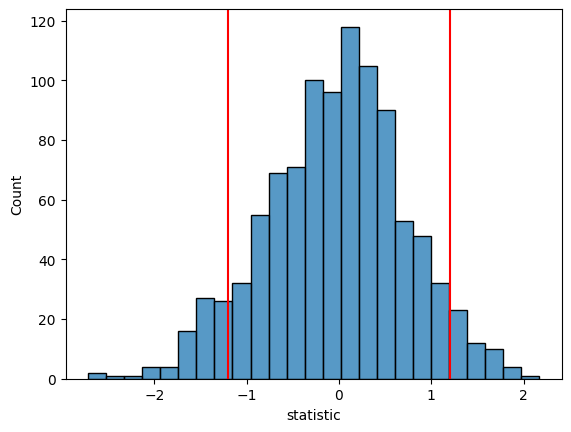

In [6]:
# Let's also visualize the observed departure delay in context of our sampling distribution.
sns.histplot(sample_means["statistic"])
plt.axvline(delay_diff, color='red')

plt.axvline(-delay_diff, color='red')

In [7]:
# Wait a second... are we sure this is really significant?

# Looking at our observe difference (red line), could we really have a p-value of zero? Strange, because it is definitely well within the distribution.
# So that p-value cannot be zero. We see many other values on the right of the red line. And we are only looking at the right side of the distribution.
# So we need to investigate what is causing the p-value to be zero.

# p-value is dependant on the absolute value of the sample_means and delay_diff. 
# let's see what this gives us:


p = (np.abs(sample_means["statistic"]) == abs(delay_diff))
# np.abs(sample_means["statistic"])
# np.abs(delay_diff)
# delay_diff
# avg_dep_delay['JFK'] - avg_dep_delay['LGA']
# avg_dep_delay['JFK']
p.value_counts()

# this shows everything is false in p-value, which means nothing in the sample_means is equal to delay_diff.
# we should be testing for anything greater than or equal when doing the comparison. It should be >= instead of ==.

statistic
False    1000
Name: count, dtype: int64